# Wisconsin Diagnostic Cancer Dataset - Análise Exploratória

### Resumo
A análise exploratória do Wisconsin Diagnostic Cancer Dataset permitiu identificar diversas correlações entre as características dos núcleos celulares e o diagnóstico (Maligno ou Benigno). Variáveis como 'concave points_worst', 'perimeter_worst' e 'radius_worst' apresentaram correlações positivas fortes com o diagnóstico maligno, indicando que valores mais elevados nessas características estão associados a uma maior probabilidade de malignidade. As visualizações confirmam que as distribuições dessas características diferem significativamente entre os casos benignos e malignos, validando sua importância para fins de diagnóstico e classificação.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
import seaborn as sns

os.makedirs("graficos", exist_ok=True)
os.makedirs("tabelas", exist_ok=True)

In [42]:
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

Path to dataset files: /home/mrpunkdasilva/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2


In [43]:
df = pd.read_csv(os.path.join(path, "data.csv"))
df.head().to_csv("tabelas/wisconsin_primeiras_linhas.csv", index=False)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [44]:
df.shape

(569, 33)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [46]:
df.describe().to_csv("tabelas/wisconsin_estatisticas.csv")
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [47]:
null_counts = df.isnull().sum()
null_counts.to_csv("tabelas/wisconsin_valores_nulos.csv", header=["valores_nulos"])
print(null_counts)

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [48]:
df = df.drop(columns=["Unnamed: 32"], errors="ignore")

In [49]:
diag_counts = df["diagnosis"].value_counts()
diag_counts.to_csv("tabelas/wisconsin_distribuicao_diagnostico.csv", header=["contagem"])
print(diag_counts)

diagnosis
B    357
M    212
Name: count, dtype: int64


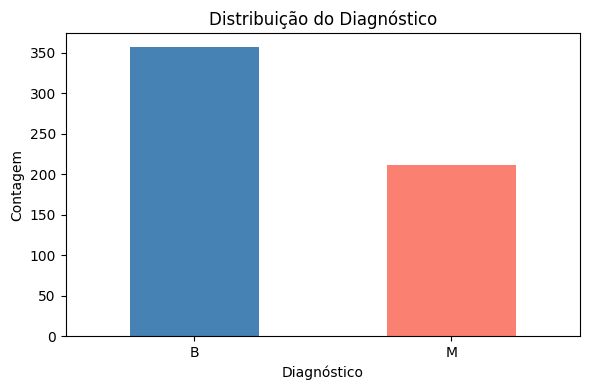

In [50]:
plt.figure(figsize=(6, 4))
df["diagnosis"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribuição do Diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("graficos/wisconsin_distribuicao_diagnostico.png", dpi=150, bbox_inches="tight")
plt.show()

In [51]:
features = df.columns[2:32]
feature_groups = {
    "mean": [f for f in features if f.endswith("_mean")],
    "se": [f for f in features if f.endswith("_se")],
    "worst": [f for f in features if f.endswith("_worst")]
}

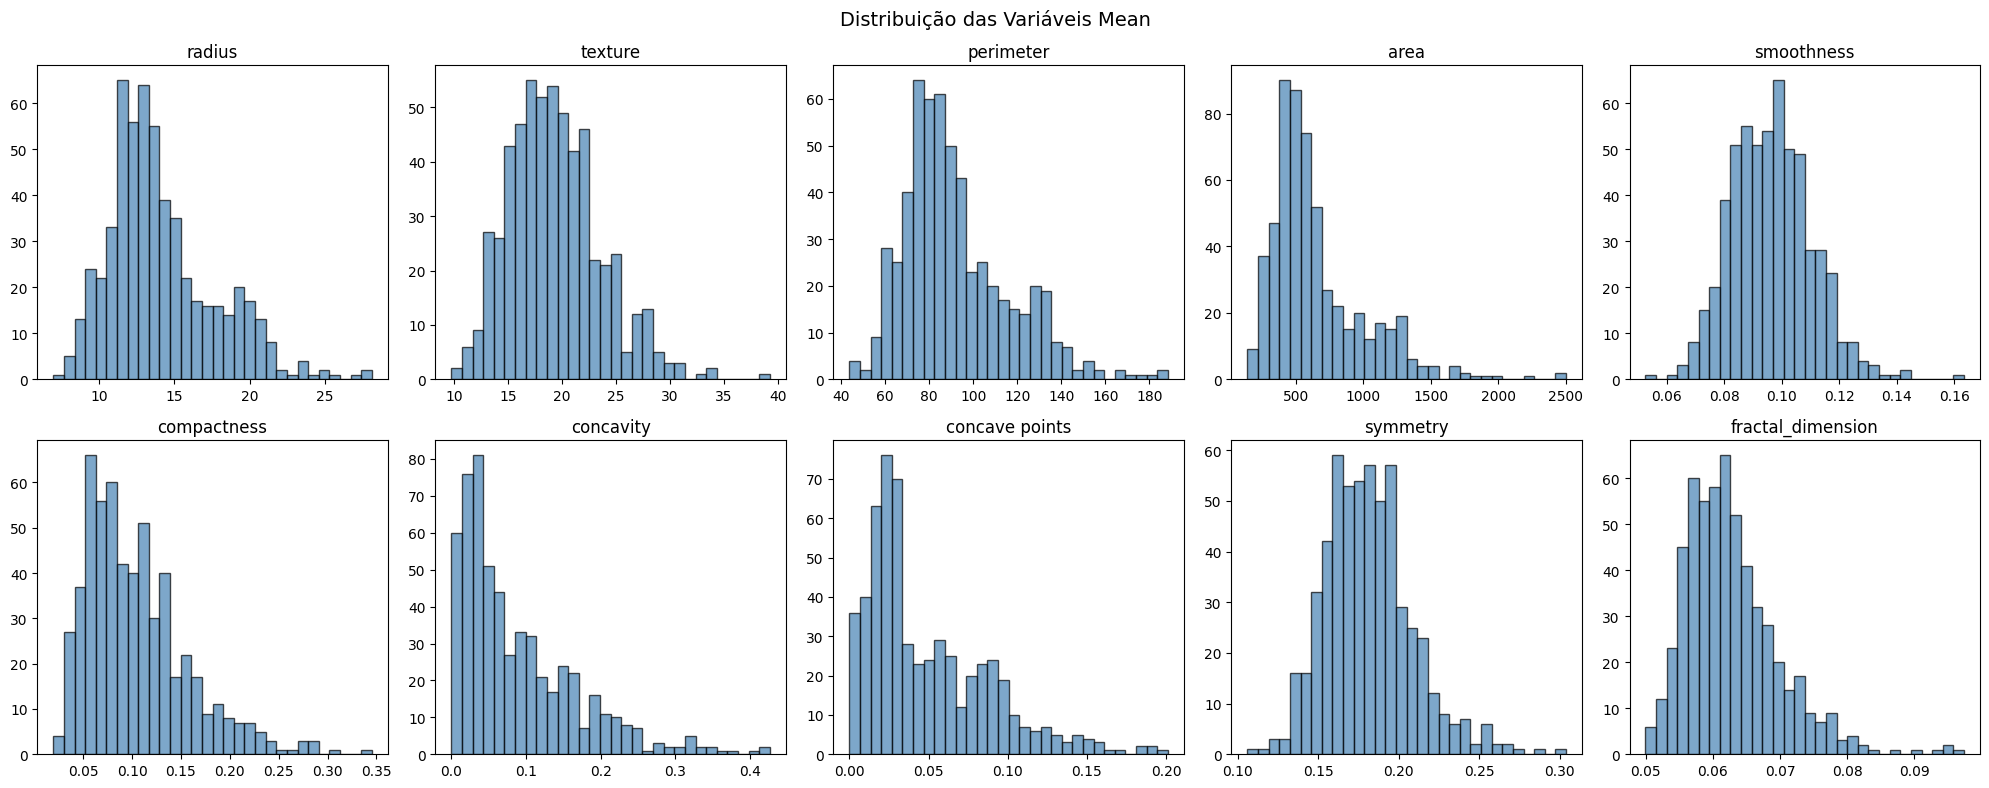

In [52]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, feat in enumerate(feature_groups["mean"]):
    row, col = i // 5, i % 5
    ax = axes[row, col]
    ax.hist(df[feat], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(feat.replace("_mean", ""))
plt.suptitle("Distribuição das Variáveis Mean", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/wisconsin_histogramas_mean.png", dpi=150, bbox_inches="tight")
plt.show()

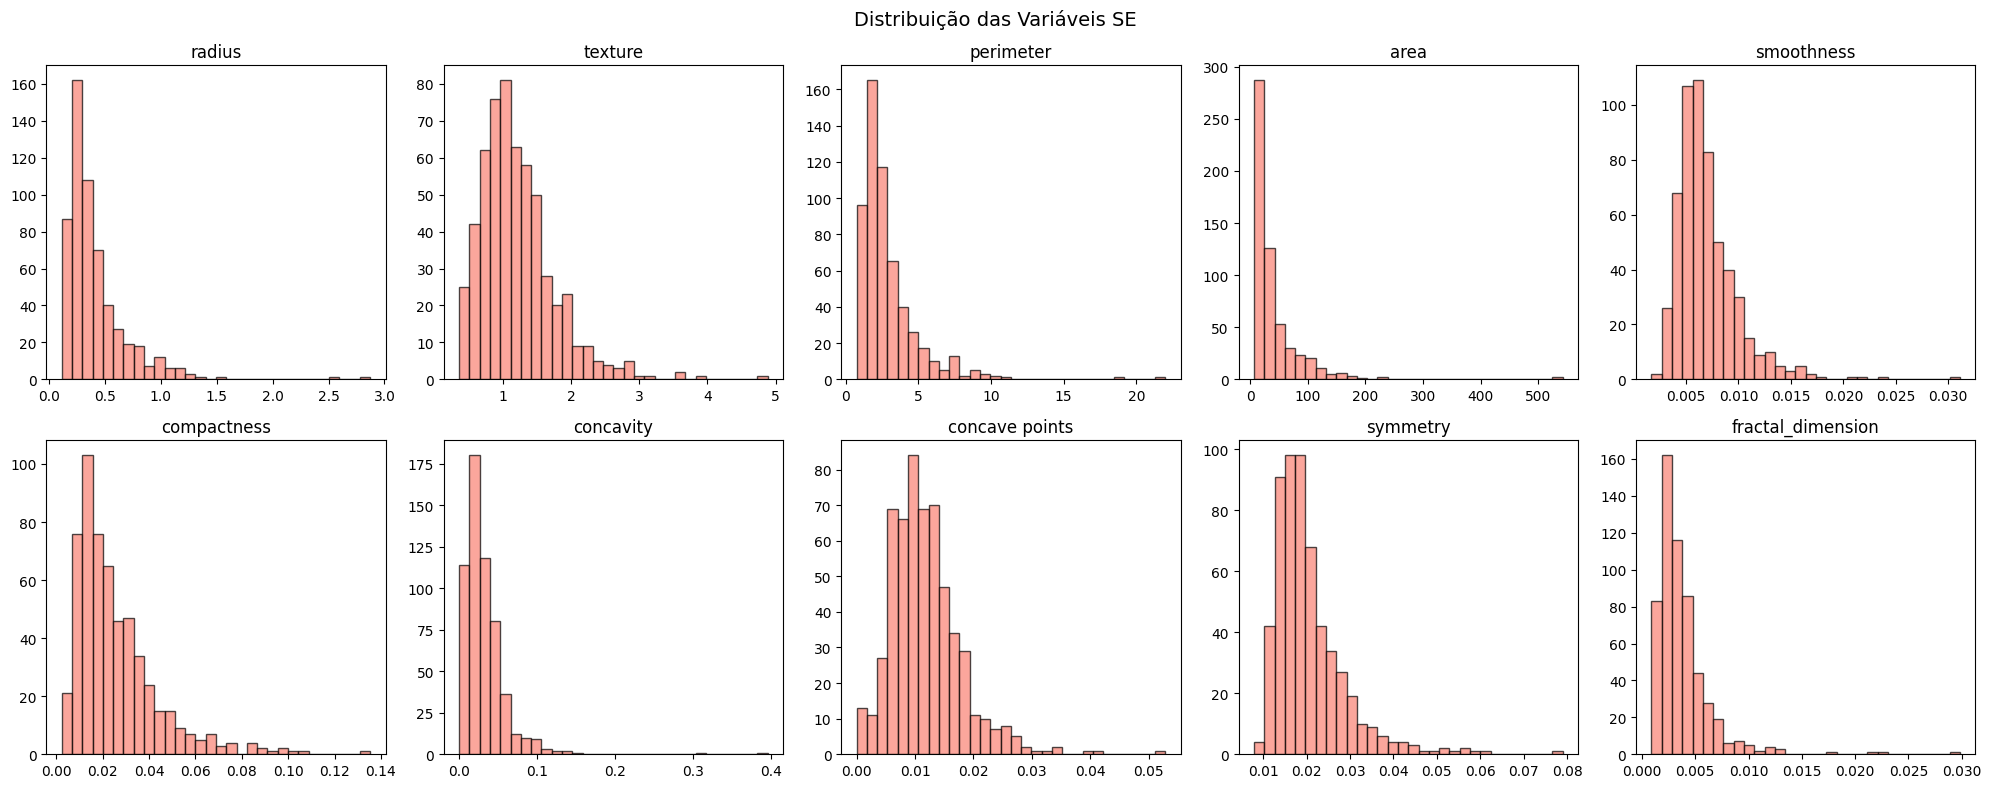

In [53]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, feat in enumerate(feature_groups["se"]):
    row, col = i // 5, i % 5
    ax = axes[row, col]
    ax.hist(df[feat], bins=30, color="salmon", edgecolor="black", alpha=0.7)
    ax.set_title(feat.replace("_se", ""))
plt.suptitle("Distribuição das Variáveis SE", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/wisconsin_histogramas_se.png", dpi=150, bbox_inches="tight")
plt.show()

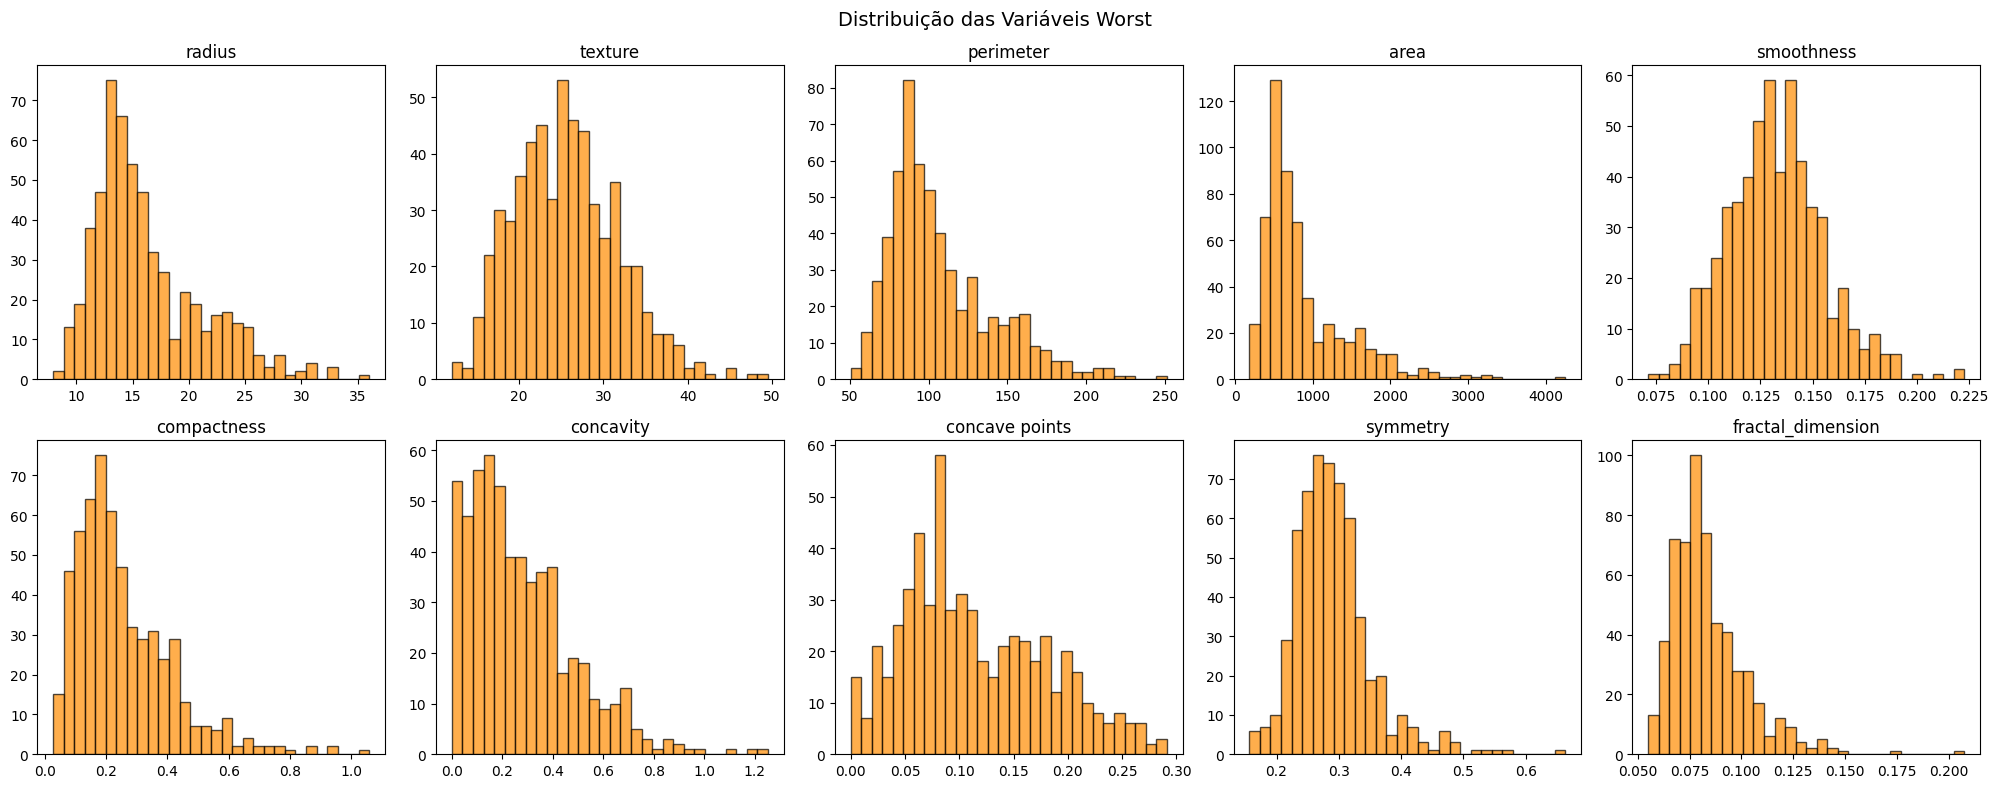

In [54]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, feat in enumerate(feature_groups["worst"]):
    row, col = i // 5, i % 5
    ax = axes[row, col]
    ax.hist(df[feat], bins=30, color="darkorange", edgecolor="black", alpha=0.7)
    ax.set_title(feat.replace("_worst", ""))
plt.suptitle("Distribuição das Variáveis Worst", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/wisconsin_histogramas_worst.png", dpi=150, bbox_inches="tight")
plt.show()

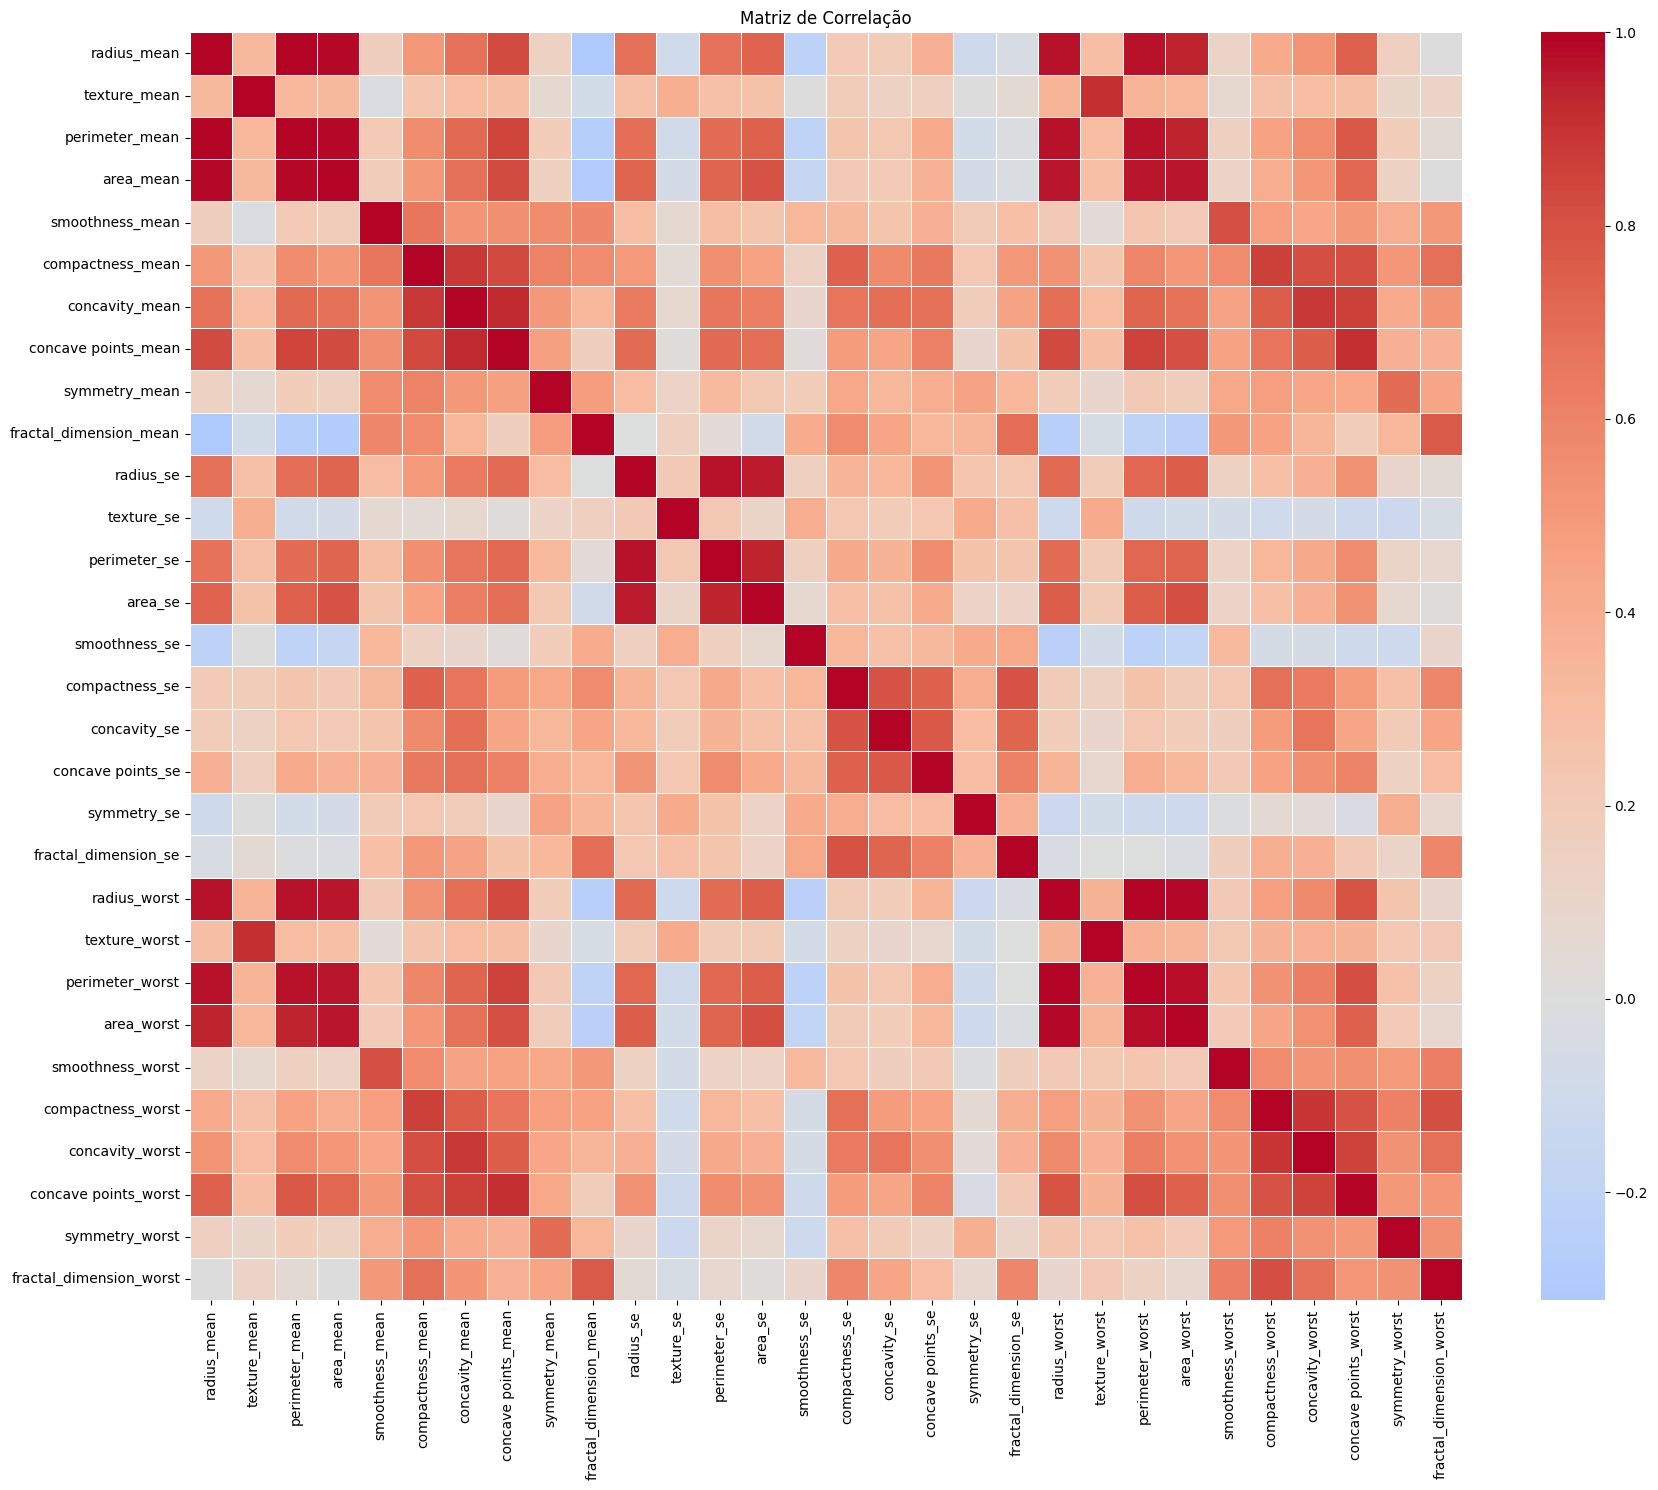

In [55]:
corr_matrix = df[features].corr()
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, fmt=".1f", linewidths=0.5)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.savefig("graficos/wisconsin_matriz_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
df_encoded = df.copy()
df_encoded["diagnosis"] = df_encoded["diagnosis"].map({"M": 1, "B": 0})
corr_with_diagnosis = df_encoded[features.tolist() + ["diagnosis"]].corr()["diagnosis"].drop("diagnosis")
corr_with_diagnosis.sort_values(ascending=False).to_csv("tabelas/wisconsin_correlacao_diagnostico.csv", header=["correlacao"])
print(corr_with_diagnosis.sort_values(ascending=False))

concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0.006522
texture_se                -0

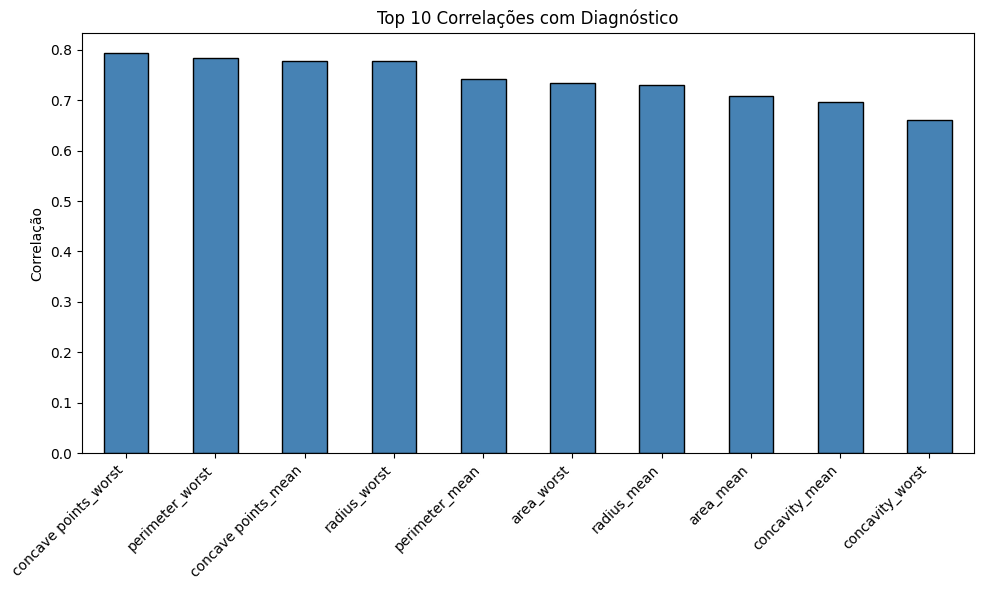

In [57]:
top_features = corr_with_diagnosis.abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 6))
corr_with_diagnosis[top_features].plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Correlações com Diagnóstico")
plt.ylabel("Correlação")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("graficos/wisconsin_top10_correlacoes.png", dpi=150, bbox_inches="tight")
plt.show()

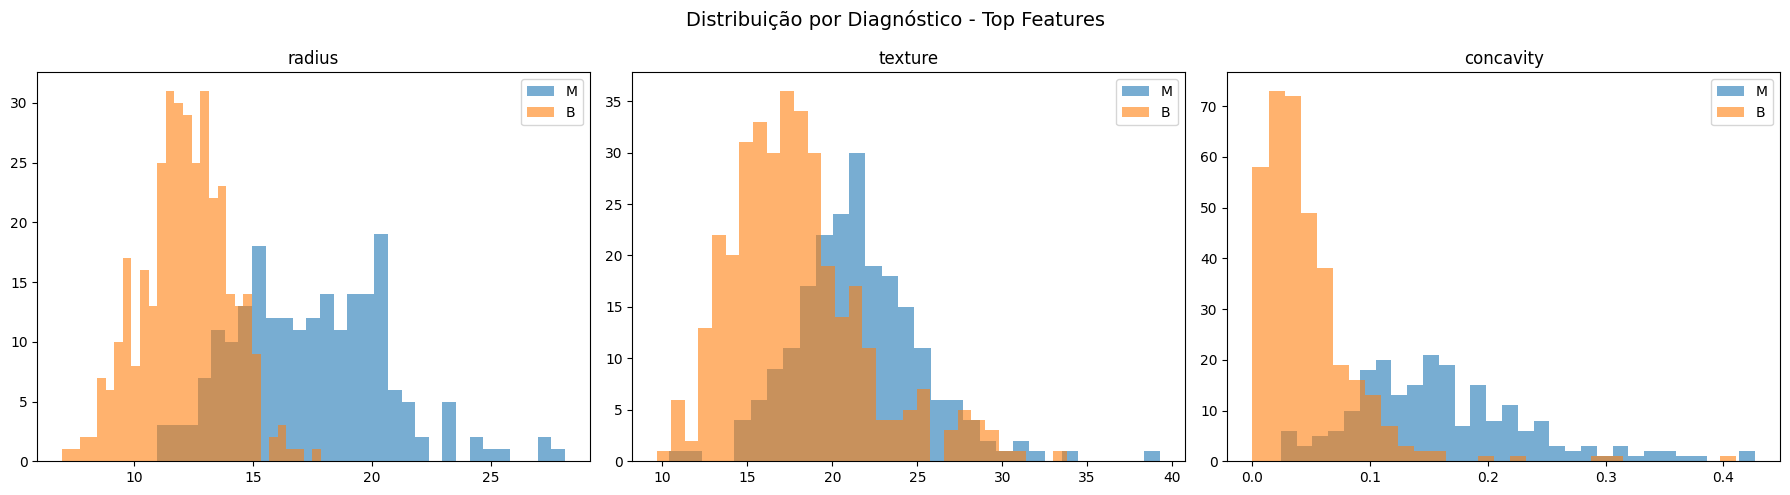

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(["radius_mean", "texture_mean", "concavity_mean"]):
    ax = axes[i]
    for diag in ["M", "B"]:
        subset = df[df["diagnosis"] == diag]
        ax.hist(subset[feat], bins=30, alpha=0.6, label=diag)
    ax.set_title(feat.replace("_mean", ""))
    ax.legend()
plt.suptitle("Distribuição por Diagnóstico - Top Features", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/wisconsin_distribuicao_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

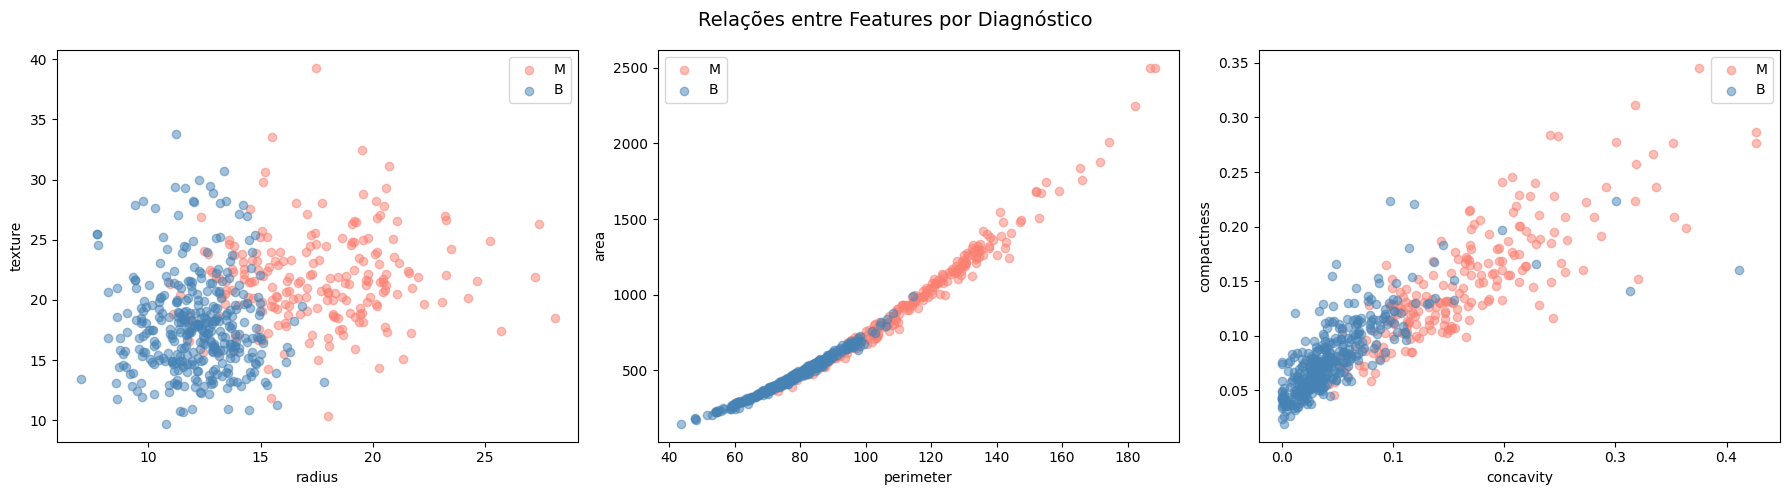

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [("radius_mean", "texture_mean"), ("perimeter_mean", "area_mean"), ("concavity_mean", "compactness_mean")]
for i, (x, y) in enumerate(pairs):
    ax = axes[i]
    for diag, color in [("M", "salmon"), ("B", "steelblue")]:
        subset = df[df["diagnosis"] == diag]
        ax.scatter(subset[x], subset[y], c=color, alpha=0.5, label=diag)
    ax.set_xlabel(x.replace("_mean", ""))
    ax.set_ylabel(y.replace("_mean", ""))
    ax.legend()
plt.suptitle("Relações entre Features por Diagnóstico", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/wisconsin_scatter_features.png", dpi=150, bbox_inches="tight")
plt.show()

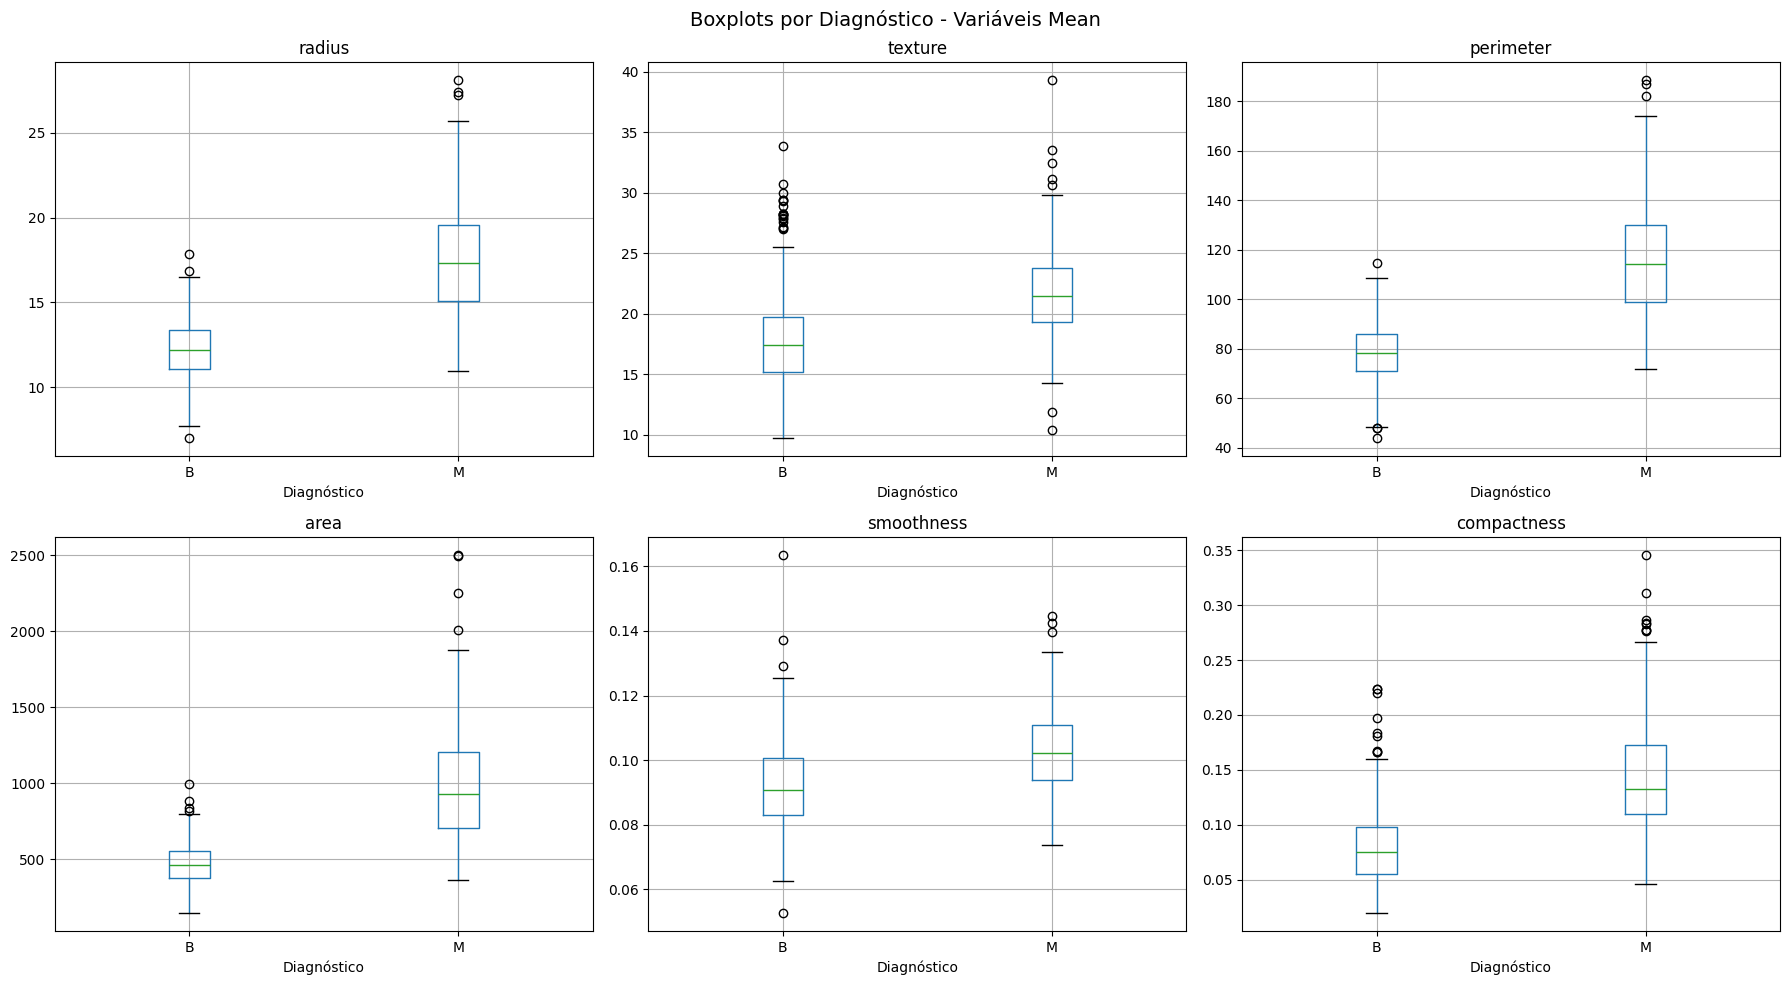

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
mean_feats = feature_groups["mean"][:6]
for i, feat in enumerate(mean_feats):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    df.boxplot(column=feat, by="diagnosis", ax=ax)
    ax.set_title(feat.replace("_mean", ""))
    ax.set_xlabel("Diagnóstico")
plt.suptitle("Boxplots por Diagnóstico - Variáveis Mean", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/wisconsin_boxplots_diagnostico.png", dpi=150, bbox_inches="tight")
plt.show()